# TERCERA EVALUACIÓN DEL CURSO
**PROYECTO INTEGRADO DE MACHINE LEARNING PARA MARKETING BANCARIO**


Este notebook se desarrolla la segmentación y predicción de contratación de depósitos a plazo para el Banco de Portugal, utilizando el dataset clásico de Bank Marketing (UCI).

La estructura sigue la rúbrica de evaluación:

Planteamiento del problema y justificación del dataset.
Análisis exploratorio de datos (EDA).
Preprocesamiento (encoding, escalamiento, partición train/valid/test).
Métodos no supervisados (PCA y K-Means).
Modelo baseline (Regresión Logística).
Modelos avanzados con GridSearchCV: SVM, Random Forest, Gradient Boosting y XGBoost.
Comparación de modelos usando AUC y F1.
Conclusión ejecutiva para la gerencia de marketing.

# 1. Planteamiento del problema
El Banco de Portugal quiere promocionar depósitos a plazo a través de llamadas telefónicas. Llamar a todos los clientes sería caro y poco eficiente, por lo que necesitamos un modelo de machine learning que:

Estime la probabilidad de que un cliente acepte el depósito (y = "yes").

Permita clasificar a los clientes en grupos similares, para aplicar estrategias de marketing más personalizadas y efectivas.

**Tipo de problema**
Desde la perspectiva de ML, se trata de un problema de clasificación binaria, donde las clases están desbalanceadas (muchos más clientes que no contratan que los que sí) y las variables son mezcla de numéricas y categóricas.

**Dataset Bank Marketing (UCI)**
El dataset Bank Marketing contiene información sobre clientes de un banco portugués, incluyendo datos socio-demográficos, financieros y de interacciones previas con campañas. Es muy usado en investigación y enseñanza porque:


*   Refleja un escenario realista de marketing bancario.

*   Tiene suficiente tamaño para probar modelos avanzados y métodos de validación robustos.

*   Contiene variables de distintos tipos (edad, saldo, profesión, estado civil, historial de campañas, etc.), lo que permite construir pipelines completos de procesamiento de datos y modelado.



In [1]:
# =============================================================
# PARTE 1 — IMPORTS Y CONFIGURACIÓN INICIAL
# =============================================================


import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report


try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False


# Output directory
OUTDIR = "results"
os.makedirs(OUTDIR, exist_ok=True)

In [2]:
# =============================================================
# PARTE 2 — CARGA DEL DATASET DESDE URL
# =============================================================

import pandas as pd
import zipfile
import urllib.request

# URL del archivo ZIP
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"

# Descargar el archivo ZIP
urllib.request.urlretrieve(url, "bank-additional.zip")

# Descomprimir el ZIP
with zipfile.ZipFile("bank-additional.zip", 'r') as zip_ref:
    zip_ref.extractall(".")

# Cargar el CSV dentro de la carpeta extraída
df = pd.read_csv("bank-additional/bank-additional-full.csv", sep=';')

# Vista previa
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# Descripción de Variables – Dataset Bank Additional Full (UCI)

## Variables demográficas del cliente

| Variable    | Tipo       | Descripción |
|------------|------------|-------------|
| `age`      | Numérica   | Edad del cliente en años. |
| `job`      | Categórica | Tipo de trabajo del cliente (e.g., admin., services, housemaid, management). |
| `marital`  | Categórica | Estado civil del cliente (`married`, `single`, `divorced`). |
| `education`| Categórica | Nivel de educación del cliente (`basic.4y`, `high.school`, `university.degree`, `professional.course`, `unknown`). |
| `default`  | Binaria (`yes`/`no`) | Indica si el cliente tiene crédito en default. |
| `housing`  | Binaria (`yes`/`no`) | Indica si el cliente tiene un préstamo hipotecario. |
| `loan`     | Binaria (`yes`/`no`) | Indica si el cliente tiene un préstamo personal. |

---

## Variables relacionadas con la campaña de marketing

| Variable      | Tipo       | Descripción |
|---------------|------------|-------------|
| `contact`     | Categórica | Tipo de comunicación con el cliente (`telephone` o `cellular`). |
| `month`       | Categórica | Mes en que se contactó al cliente (`jan`, `feb`, ..., `dec`). |
| `day_of_week` | Categórica | Día de la semana del contacto (`mon`, `tue`, ..., `fri`). |
| `duration`    | Numérica   | Duración de la última llamada en segundos. **No usar para predicción antes del contacto**. |
| `campaign`    | Numérica   | Número de contactos realizados durante esta campaña para este cliente. |
| `pdays`       | Numérica   | Número de días desde la última campaña hasta este contacto. Valor `999` significa que no fue contactado previamente. |
| `previous`    | Numérica   | Número de contactos realizados antes de esta campaña. |
| `poutcome`    | Categórica | Resultado de la campaña anterior (`success`, `failure`, `other`, `nonexistent`). |

---

## Variables económicas y de contexto

| Variable         | Tipo     | Descripción |
|-----------------|----------|-------------|
| `emp.var.rate`   | Numérica | Tasa de variación del empleo trimestral. |
| `cons.price.idx` | Numérica | Índice de precios al consumidor (IPC). |
| `cons.conf.idx`  | Numérica | Índice de confianza del consumidor. |
| `euribor3m`      | Numérica | Tasa Euribor a 3 meses. |
| `nr.employed`    | Numérica | Número de empleados registrados en ese periodo. |

---

## Variable objetivo

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `y`      | Binaria (`yes`/`no`) | Indica si el cliente suscribió un depósito a plazo tras la campaña. |

---

### Notas importantes

- `duration` **no debe usarse como predictor** si se busca predecir `y` antes de contactar al cliente.  
- Valores `999` en `pdays` indican que el cliente **no fue contactado previamente**.  
- Valores `unknown` en variables categóricas (`job`, `education`, etc.) pueden manejarse como categoría propia o imputarse según criterio.  


# 2. EDA y análisis descriptivo

                  count unique                top   freq         mean  \
age             41188.0    NaN                NaN    NaN     40.02406   
job               41188     12             admin.  10422          NaN   
marital           41188      4            married  24928          NaN   
education         41188      8  university.degree  12168          NaN   
default           41188      3                 no  32588          NaN   
housing           41188      3                yes  21576          NaN   
loan              41188      3                 no  33950          NaN   
contact           41188      2           cellular  26144          NaN   
month             41188     10                may  13769          NaN   
day_of_week       41188      5                thu   8623          NaN   
duration        41188.0    NaN                NaN    NaN    258.28501   
campaign        41188.0    NaN                NaN    NaN     2.567593   
pdays           41188.0    NaN                NaN  

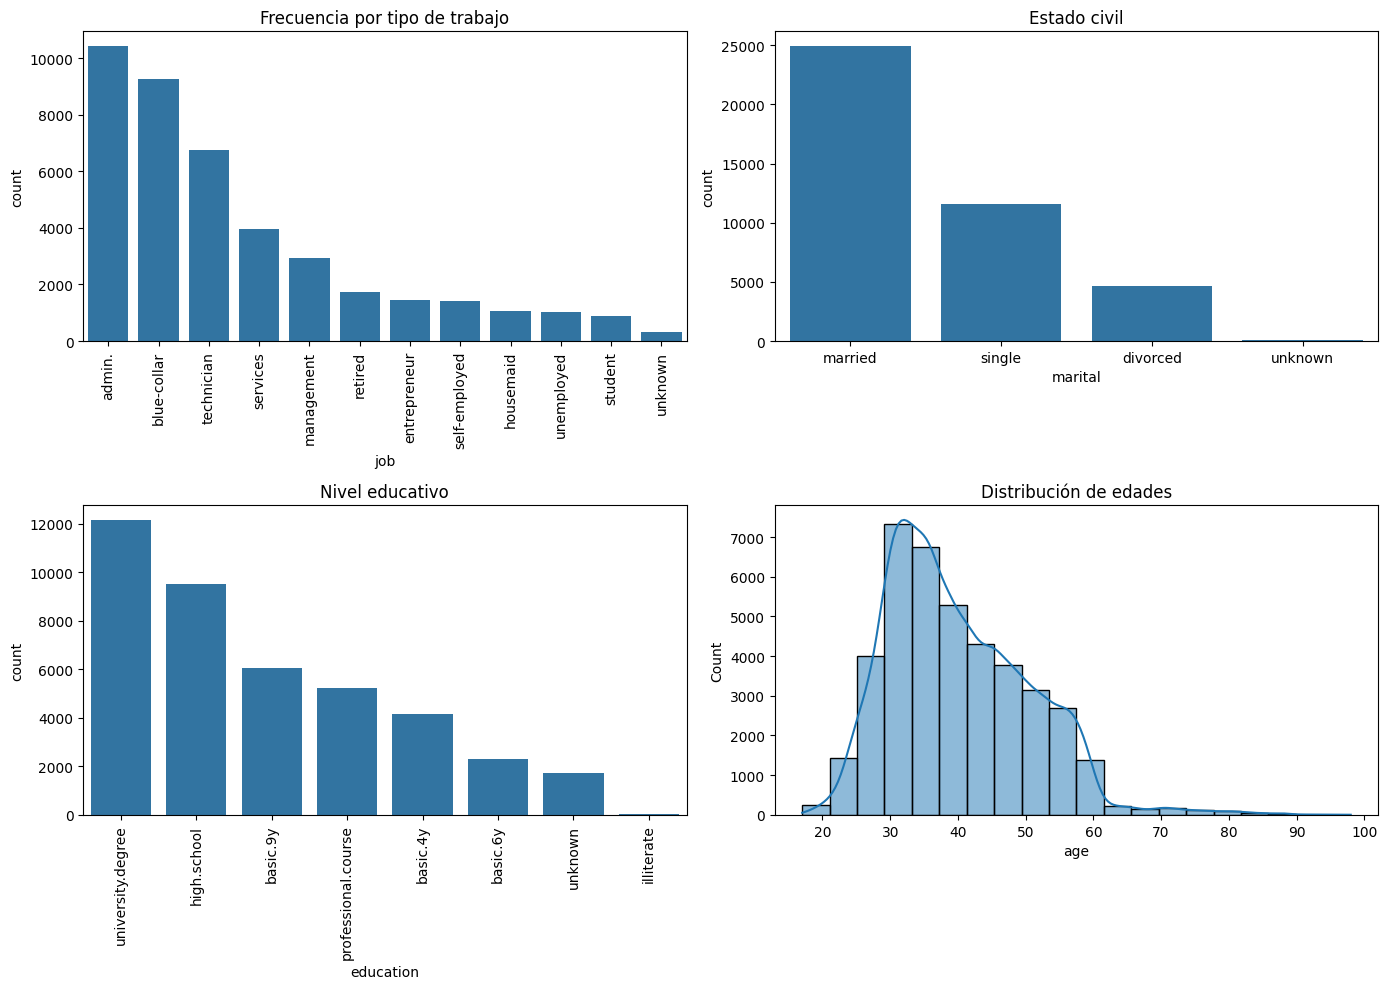

/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_5576/450464131.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  corr = df[numeric_cols + ['y']].replace({"yes":1,"no":0}).corr()


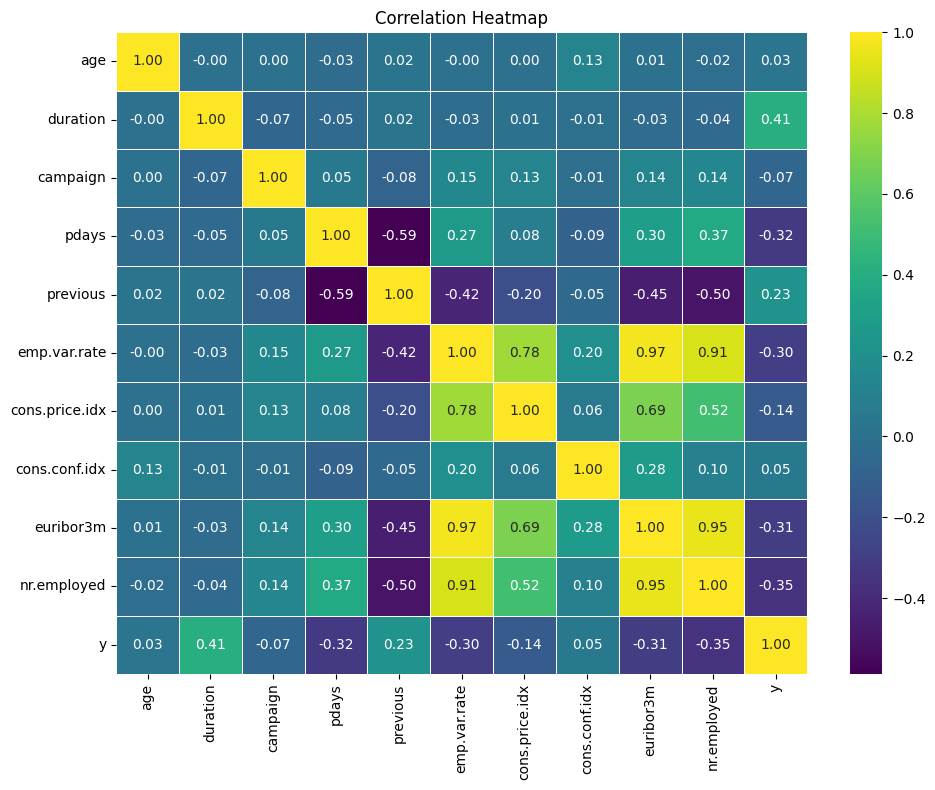

=== MATRIZ DE CORRELACIÓN ===
                  age  duration  campaign  pdays  previous  emp.var.rate  \
age             1.000    -0.001     0.005 -0.034     0.024        -0.000   
duration       -0.001     1.000    -0.072 -0.048     0.021        -0.028   
campaign        0.005    -0.072     1.000  0.053    -0.079         0.151   
pdays          -0.034    -0.048     0.053  1.000    -0.588         0.271   
previous        0.024     0.021    -0.079 -0.588     1.000        -0.420   
emp.var.rate   -0.000    -0.028     0.151  0.271    -0.420         1.000   
cons.price.idx  0.001     0.005     0.128  0.079    -0.203         0.775   
cons.conf.idx   0.129    -0.008    -0.014 -0.091    -0.051         0.196   
euribor3m       0.011    -0.033     0.135  0.297    -0.454         0.972   
nr.employed    -0.018    -0.045     0.144  0.373    -0.501         0.907   
y               0.030     0.405    -0.066 -0.325     0.230        -0.298   

                cons.price.idx  cons.conf.idx  euribor3m 

In [3]:
# =============================================================
# PARTE 3 — EDA COMPLETA
# =============================================================

# --- Listado de columnas numéricas y categóricas ---
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(df.describe(include='all').T)

# Convertir todas las variables categóricas a dummies
df_num = pd.get_dummies(df, drop_first=True)

# =============================================================
# FRECUENCIA DE VARIABLES DEMOGRÁFICAS
# =============================================================

fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.countplot(data=df, x="job", ax=axes[0,0], order=df['job'].value_counts().index)
axes[0,0].set_title("Frecuencia por tipo de trabajo")
axes[0,0].tick_params(axis='x', rotation=90)

sns.countplot(data=df, x="marital", ax=axes[0,1])
axes[0,1].set_title("Estado civil")

sns.countplot(data=df, x="education", ax=axes[1,0], order=df['education'].value_counts().index)
axes[1,0].set_title("Nivel educativo")
axes[1,0].tick_params(axis='x', rotation=90)

sns.histplot(df['age'], bins=20, kde=True, ax=axes[1,1])
axes[1,1].set_title("Distribución de edades")

plt.tight_layout()
plt.show()


# --- Heatmap de correlación ---
plt.figure(figsize=(10,8))

corr = df[numeric_cols + ['y']].replace({"yes":1,"no":0}).corr()

sns.heatmap(
    corr,
    cmap='viridis',
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# --- Mostrar valores numéricos ---
print("=== MATRIZ DE CORRELACIÓN ===")
print(corr.round(3))

print("\n=== CORRELACIÓN CON Y (ordenada) ===")
print(corr['y'].sort_values(ascending=False).round(3))

# Correlaciones más importantes con la variable objetivo y:
Correlaciones positivas con y:

**Variables que aumentan junto con la probabilidad de suscripción:**

duration: +0.405
(Llamadas más largas → mayor probabilidad de suscribir)

previous: +0.230
(Clientes contactados antes → más probabilidad)

cons.conf.idx: +0.055
(Confianza del consumidor ligeramente relacionada)

age: +0.030
(Relación débil pero positiva)

Correlaciones negativas con y

**Variables que disminuyen cuando aumenta la probabilidad de suscripción**

nr.employed: –0.355

pdays: –0.325

euribor3m: –0.308

emp.var.rate: –0.298

cons.price.idx: –0.136

campaign: –0.066

Interpretación general:

**Tasas de interés más bajas y menor número de contactos aumentan la suscripción.**

**Más días desde último contacto disminuye la probabilidad**

**Conclusión general**

**duration es la variable más predictiva.**

Factores económicos como nr.employed, euribor3m y emp.var.rate influyen de forma moderada.

Variables como edad y precio tienen influencia débil.

# 3. Preprocesamiento e implementacion de modelo no supervisaco PCA

Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Variables categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


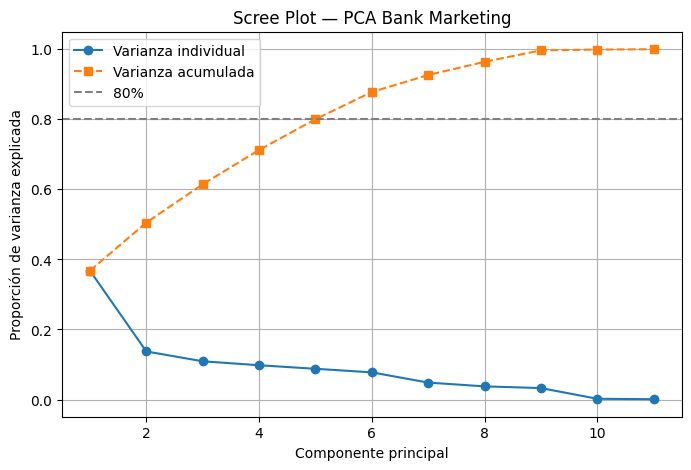


Varianza explicada por componente:
[0.3678 0.1374 0.1092 0.098  0.0878 0.0777 0.0485 0.0376 0.0328 0.0023
 0.001 ]

Varianza acumulada:
[0.3678 0.5052 0.6144 0.7124 0.8002 0.8778 0.9263 0.9639 0.9968 0.999
 1.    ]

👉 Número óptimo de componentes para 80% de varianza: 5

=== LOADINGS (CARGAS) ===


,PC1,PC2,PC3,PC4,PC5
age,-0.004,0.164,-0.228,0.647,0.390
duration,-0.053,0.411,0.658,-0.003,0.119
campaign,0.099,-0.033,-0.179,-0.299,0.875
pdays,0.235,-0.466,0.383,0.249,0.106
previous,-0.302,0.279,-0.372,-0.277,-0.102
emp.var.rate,0.473,0.191,-0.043,-0.093,-0.058
cons.price.idx,0.349,0.292,-0.085,-0.279,-0.036
cons.conf.idx,0.089,0.353,-0.247,0.516,-0.118
euribor3m,0.476,0.177,-0.039,-0.004,-0.072
nr.employed,0.461,0.037,0.037,-0.031,-0.037



=== Top variables por PC ===

PC1:
euribor3m         0.476
emp.var.rate      0.473
nr.employed       0.461
cons.price.idx    0.349
previous          0.302
Name: PC1, dtype: float64

PC2:
y_bin             0.479
pdays             0.466
duration          0.411
cons.conf.idx     0.353
cons.price.idx    0.292
Name: PC2, dtype: float64

PC3:
duration         0.658
pdays            0.383
previous         0.372
y_bin            0.353
cons.conf.idx    0.247
Name: PC3, dtype: float64

PC4:
age               0.647
cons.conf.idx     0.516
campaign          0.299
cons.price.idx    0.279
previous          0.277
Name: PC4, dtype: float64

PC5:
campaign         0.875
age              0.390
y_bin            0.147
duration         0.119
cons.conf.idx    0.118
Name: PC5, dtype: float64


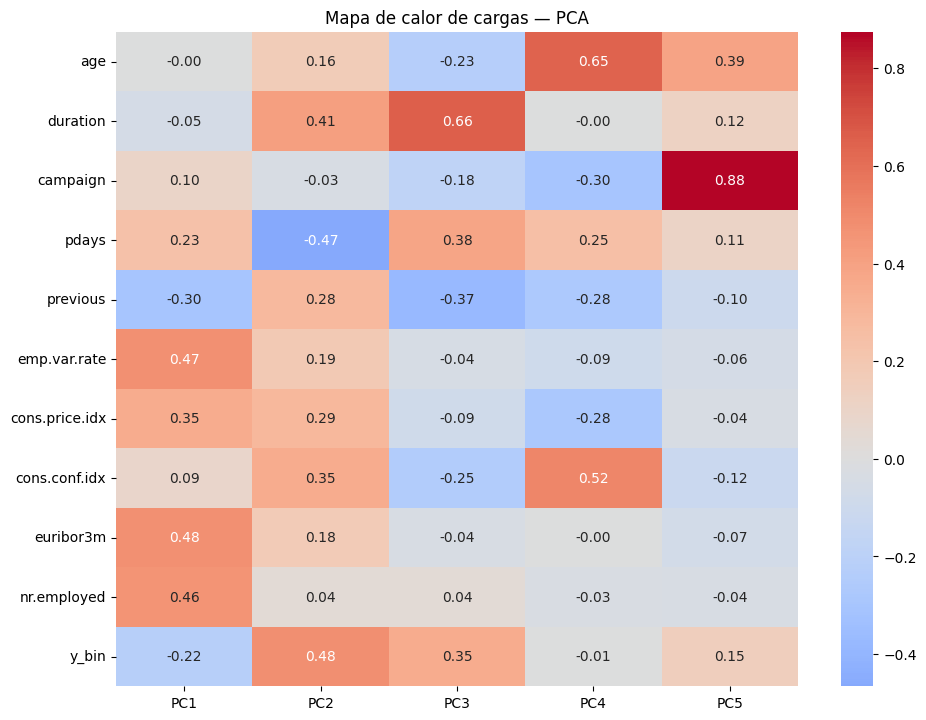

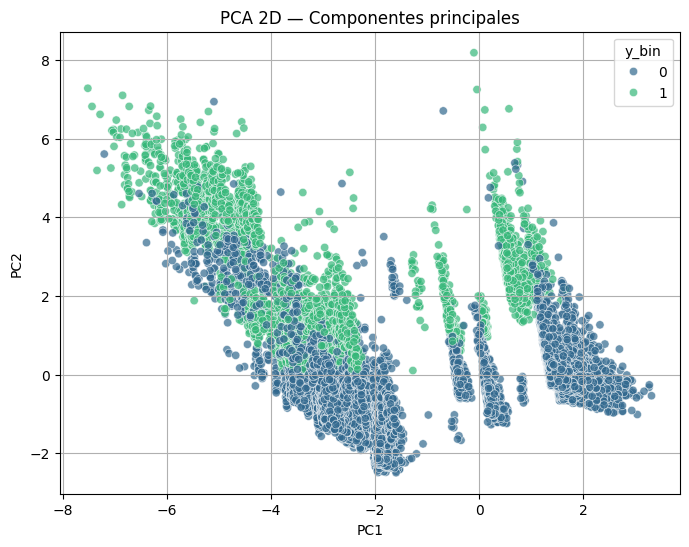


=== LOADINGS 2D (PC1 y PC2) ===


,PC1,PC2
age,-0.004,0.164
duration,-0.053,0.411
campaign,0.099,-0.033
pdays,0.235,-0.466
previous,-0.302,0.279
emp.var.rate,0.473,0.191
cons.price.idx,0.349,0.292
cons.conf.idx,0.089,0.353
euribor3m,0.476,0.177
nr.employed,0.461,0.037


/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_5576/3792720035.py:172: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings_2d.PC1[i]*3,  # multiplicador para que se vea
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_5576/3792720035.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  loadings_2d.PC2[i]*3,
/var/folders/hm/gl5g7h3x4018gcwv2bfzhzr40000gn/T/ipykernel_5576/3792720035.py:176: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by posi

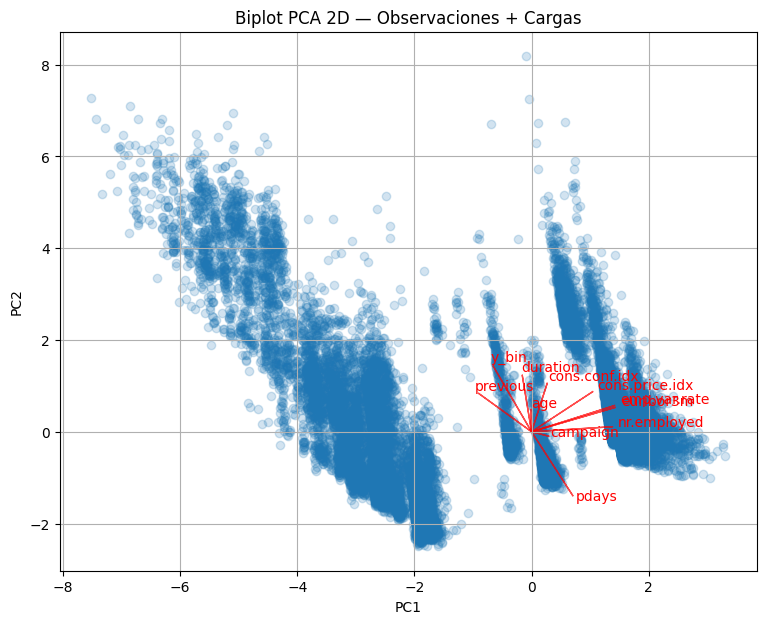

In [4]:
# =============================================================
# IMPORTS
# =============================================================
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =============================================================
# 1. CREAR Y_BIN DE MANERA SEGURA
# =============================================================

if 'y_bin' not in df.columns:
    df['y_bin'] = df['y'].map({'yes': 1, 'no': 0})

# =============================================================
# 2. DEFINIR X E Y
# =============================================================

X = df.drop(columns=['y', 'y_bin'])
y = df['y_bin']

# Columnas numéricas y categóricas
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

print("Variables numéricas:", numeric_cols)
print("Variables categóricas:", cat_cols)

# =============================================================
# 3. TRAIN / VAL / TEST
# =============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

# =============================================================
# 4. COLUMNTRANSFORMER PARA MODELOS (NO PARA PCA)
# =============================================================

preprocess = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), numeric_cols)
])

# =============================================================
# 5. PCA EXPLORATORIO (SOLO NUMÉRICAS)
# =============================================================

# Selección de solo numéricas
num_cols = df.select_dtypes(include=[np.number]).columns
X_num = df[num_cols]

# Estandarizar
scaler = StandardScaler()
Z = scaler.fit_transform(X_num)

# PCA exploratorio
pca = PCA()
Z_pca = pca.fit_transform(Z)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, 'o-', label='Varianza individual')
plt.plot(range(1, len(cum_var)+1), cum_var, 's--', label='Varianza acumulada')
plt.axhline(y=0.80, color='gray', linestyle='--', label='80%')
plt.title('Scree Plot — PCA Bank Marketing')
plt.xlabel('Componente principal')
plt.ylabel('Proporción de varianza explicada')
plt.grid(True)
plt.legend()
plt.show()

print("\nVarianza explicada por componente:")
print(np.round(explained_var, 4))

print("\nVarianza acumulada:")
print(np.round(cum_var, 4))

# Número óptimo de componentes para explicar ≥ 80%
n_components = np.argmax(cum_var >= 0.80) + 1
print(f"\n👉 Número óptimo de componentes para 80% de varianza: {n_components}")

# =============================================================
# 6. PCA FINAL CON N_COMPONENTS
# =============================================================

pca_final = PCA(n_components=n_components)
Z_pca_final = pca_final.fit_transform(Z)

# Loadings (cargas)
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=num_cols,
    columns=[f"PC{i+1}" for i in range(n_components)]
).round(3)

print("\n=== LOADINGS (CARGAS) ===")
display(loadings)

# Variables más influyentes por componente
print("\n=== Top variables por PC ===")
for pc in loadings.columns:
    print(f"\n{pc}:")
    print(loadings[pc].abs().sort_values(ascending=False).head(5))

# Heatmap de loadings
plt.figure(figsize=(1.2*n_components+5, 0.5*len(num_cols)+3))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de calor de cargas — PCA")
plt.show()

# =============================================================
# 7. PCA 2D PLOT (Solo si n_components >= 2)
# =============================================================

if n_components >= 2:

    pca_2d = PCA(n_components=2)
    Z_pca2 = pca_2d.fit_transform(Z)

    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=Z_pca2[:,0],
        y=Z_pca2[:,1],
        hue=df['y_bin'],
        palette='viridis',
        alpha=0.7
    )
    plt.title("PCA 2D — Componentes principales")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()

    # =============================================================
    # 8. LOADINGS PARA PC1 Y PC2
    # =============================================================

    loadings_2d = pd.DataFrame(
        pca_2d.components_.T,
        index=num_cols,
        columns=["PC1", "PC2"]
    )

    print("\n=== LOADINGS 2D (PC1 y PC2) ===")
    display(loadings_2d.round(3))

    # =============================================================
    # 9. GRÁFICO DE CARGAS (BIPLOT SIMPLIFICADO)
    # =============================================================

    plt.figure(figsize=(9,7))
    plt.scatter(Z_pca2[:,0], Z_pca2[:,1], alpha=0.2, label="Observaciones")

    # Arrows + labels
    for i, var in enumerate(num_cols):
        plt.arrow(0, 0,
                  loadings_2d.PC1[i]*3,  # multiplicador para que se vea
                  loadings_2d.PC2[i]*3,
                  color="red", alpha=0.7)
        plt.text(
            loadings_2d.PC1[i]*3.2,
            loadings_2d.PC2[i]*3.2,
            var,
            color="red",
            fontsize=10
        )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title("Biplot PCA 2D — Observaciones + Cargas")
    plt.grid(True)
    plt.show()

else:
    print("⚠ No se puede hacer PCA 2D porque n_components < 2.")


Con base en el Scree Plot y la varianza acumulada, se seleccionan 5 componentes principales, los cuales retienen aproximadamente el 80% de la variabilidad total del dataset.

📌 PC1 — Componente Macroeconómico/Laboral

Variables con mayor peso absoluto:

euribor3m (0.476)

emp.var.rate (0.473)

nr.employed (0.461)

cons.price.idx (0.349)

Interpretación:
Este componente captura el estado general de la economía, representado por tasas de interés, empleo y precios. Refleja ciclos macroeconómicos que condicionan la probabilidad de campaña/venta.
Es un componente externo, vinculado a la situación económica del país.

📌 PC2 — Intensidad de contacto y respuesta del cliente

Variables principales:

y_bin (0.479)

pdays (0.466)

duration (0.411)

cons.conf.idx (0.353)

Interpretación:
Este componente resume la respuesta del cliente a campañas previas y la recencia del último contacto.
PC2 diferencia clientes sensibles a llamadas vs. clientes con historial más frío.

Se puede interpretar como un componente de engagement/comportamiento histórico.

📌 PC3 — Interacciones previas y efectividad de campaña

Variables destacadas:

duration (0.658)

pdays (0.383)

previous (0.372)

y_bin (0.353)

Interpretación:
Este componente separa observaciones según la duración del contacto actual y la historia previa de intentos, lo cual está muy asociado a la probabilidad de éxito.

Es un componente que refleja efectividad del proceso de contacto.

📌 PC4 — Componente sociodemográfico y actividad de campaña

Variables clave:

age (0.647)

cons.conf.idx (0.516)

campaign (0.299)

Interpretación:
PC4 combina edad del cliente con percepción de confianza económica y número de contactos en la campaña.
Representa un componente sociodemográfico + esfuerzo comercial.

Clientes mayores y en contextos económicos desfavorables se diferencian fuertemente en este eje.

📌 PC5 — Esfuerzo de campaña (volumen de contactos)

Variables principales:

campaign (0.875)

age (0.390)

Interpretación:
Este componente está dominado casi exclusivamente por la variable campaign, por lo que captura el intensidad del contacto dentro de la campaña actual.

🎯 Conclusión general del PCA

Los 5 componentes permiten reducir dimensionalidad de 11 → 5 variables, manteniendo un 80% de la información.

Se identifican tres grandes bloques informativos:

Condiciones macroeconómicas (PC1)

Engagement / probabilidad de respuesta (PC2 y PC3)

Factores sociodemográficos y esfuerzo de campaña (PC4 y PC5)

El PCA confirma que variables como duration, pdays, previous y campaign son estructuralmente importantes para explicar el comportamiento del dataset.

El PCA permitió:

✔ Reducir el dataset a 5 componentes que resumen el 80% de la variación.
✔ Identificar dimensiones claras:
1️⃣ Estado económico
2️⃣ Respuesta/engagement
3️⃣ Intensidad de interacción
4️⃣ Perfil sociodemográfico
5️⃣ Intensidad de campañas

Esto mejora la interpretabilidad antes de clustering.

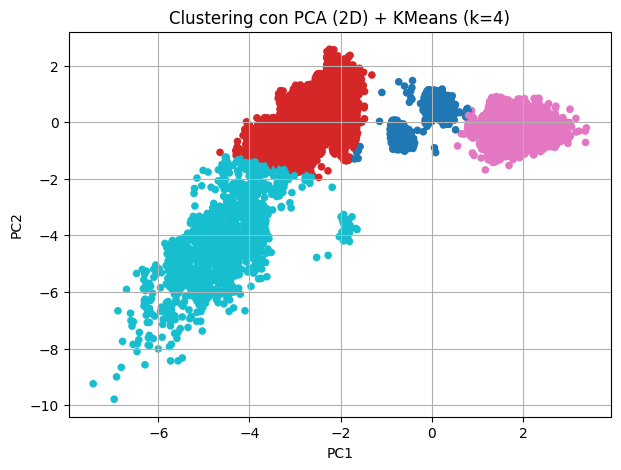

In [5]:

# =============================================================
# PARTE 10 — PCA + KMEANS (Método no supervisado)
# =============================================================

# Preprocesar X completa (numéricas escaladas + categóricas codificadas)
X_pre = preprocess.fit_transform(X)

# Reducir a 2 componentes para clustering visual
pca_km = PCA(n_components=2)
X_pca_km = pca_km.fit_transform(X_pre)

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_pca_km)

# Gráfico de clusters
plt.figure(figsize=(7,5))
plt.scatter(X_pca_km[:,0], X_pca_km[:,1], c=clusters, cmap='tab10', s=20)
plt.title('Clustering con PCA (2D) + KMeans (k=4)')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

# =============================================================
# Silhouette Score (usaremos 5 PC numéricas originales para coherencia)
# =============================================================

# Asegurar que existen al menos 5 componentes
pca_sil = PCA(n_components=min(5, Z_pca.shape[1]))
Z_pca_sil = pca_sil.fit_transform(Z)


A continuación se procede a la Creación del target binario
Se convierte la variable objetivo original y (con valores "yes"/"no") en una variable numérica binaria y_bin donde:

"no" → 0

"yes" → 1

Se revisa la distribución de clases, lo que permite identificar si existe desbalance entre quienes contratan y quienes no.

Codificación de variables categóricas
Todas las variables categóricas (excepto la target) se transforman en variables dummy mediante one-hot encoding, eliminando la primera categoría para evitar multicolinealidad. Esto genera un dataset listo para modelos que solo aceptan entradas numéricas.

Definición de variables predictoras y target

X: todas las columnas predictoras (variables independientes).

y: variable objetivo binaria (y_bin).

Separación en entrenamiento y prueba
Se divide el dataset en conjunto de entrenamiento (75%) y conjunto de prueba (25%), usando estratificación para mantener la proporción original de clases en ambos conjuntos. Esto asegura que los modelos entrenen y evalúen de manera consistente frente al desbalance de clases.

In [6]:
# ======================
# PREPARAR DATASET
# ======================
import pandas as pd
import numpy as np

# Crear variable binaria target
df["y_bin"] = df["y"].map({"no": 0, "yes": 1})

print("Distribución de y_bin:")
print(df["y_bin"].value_counts(normalize=True).rename("proportion"))

# One-hot encoding (excepto target)
cat_cols = df.select_dtypes(include="object").columns.tolist()
cat_cols.remove("y")

df_model = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print("Shape del dataset modelado:", df_model.shape)

# ======================
# DEFINIR X e Y
# ======================
y = df_model["y_bin"]
X = df_model.drop(columns=["y", "y_bin"])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=123, stratify=y)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Distribución de y_bin:
y_bin
0    0.887346
1    0.112654
Name: proportion, dtype: float64
Shape del dataset modelado: (41188, 55)
Train shape: (30891, 53)
Test shape: (10297, 53)


**5. Modelo baseline: Regresión Logística**
Antes de modelos más complejos, se construye un modelo baseline de Regresión Logística:

=== BASELINE: LOGISTIC REGRESSION ===
Accuracy: 0.8621928717102069
F1: 0.5900028893383416
ROC-AUC: 0.9386971502756885

Classification report:
               precision    recall  f1-score   support

           0       0.98      0.86      0.92      9137
           1       0.44      0.88      0.59      1160

    accuracy                           0.86     10297
   macro avg       0.71      0.87      0.75     10297
weighted avg       0.92      0.86      0.88     10297



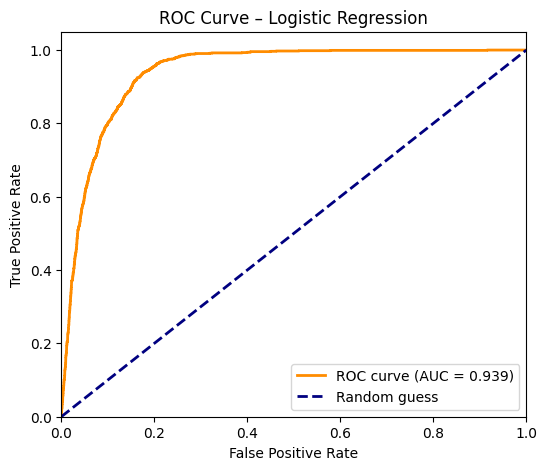

In [7]:

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ======================
# BASELINE – LOGISTIC REGRESSION
# ======================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        solver="liblinear"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print("=== BASELINE: LOGISTIC REGRESSION ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification report:\n", classification_report(y_test, y_pred))

# Calcular curvas ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Logistic Regression')
plt.legend(loc="lower right")
plt.show()


**Interpretación del baseline Regresión**

Accuracy 0.86: el modelo acierta en la mayoría de los casos, pero puede ser engañoso por el desbalance de clases.

F1 0.59 (clase positiva): buen recall (0.88) pero baja precisión (0.44), predice muchos falsos positivos.

ROC-AUC 0.94: excelente capacidad de discriminar entre quienes contratan y no.

**Conclusión**: el modelo identifica bien a los clientes que sí contratarán, pero se puede mejorar la precisión de la clase minoritaria.

6. **Función auxiliar**
Definimos una función para:

Calcular AUC, F1 y Accuracy.
Imprimir la matriz de confusión.
Esto estandariza la comparación de modelos.

In [8]:
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, confusion_matrix

def evaluate_model(name, model, X_valid, y_valid):
    """Evalúa un modelo en el set de validación e imprime métricas clave."""

    # Probabilidades y predicciones
    y_proba = model.predict_proba(X_valid)[:, 1]
    y_pred = model.predict(X_valid)

    # Métricas
    auc = roc_auc_score(y_valid, y_proba)
    f1 = f1_score(y_valid, y_pred)
    acc = accuracy_score(y_valid, y_pred)

    # Impresión de resultados
    print(f"=== {name} ===")
    print(f"AUC: {auc:.4f} | F1: {f1:.4f} | ACC: {acc:.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_valid, y_pred))
    print()

    # Retornar métricas en un diccionario
    return {'modelo': name, 'AUC': auc, 'F1': f1, 'ACC': acc}

## 7. Modelos avanzados con GridSearchCV

Entrenaremos y optimizaremos cuatro familias de modelos:

1. **SVM (SVC)** con distintos kernels.  
2. **Random Forest**.  
3. **Gradient Boosting**.  
4. **XGBoost** .

**7.1 SVM optimizado con GridSearchCV**

En esta sección entrenamos un modelo SVM para predecir la contratación del depósito (y=1) usando GridSearchCV con una grilla moderada, considerando:

Kernels: 'rbf' y 'linear'.

Parámetro C: [0.1, 1, 10] (controla la penalización de errores).

Gamma: 'scale' y 'auto' (solo relevante para RBF).

Escalado de variables: mediante StandardScaler, necesario para SVM.

Clase balanceada: class_weight='balanced' para manejar el desbalance del target.

El objetivo es encontrar la combinación de parámetros que maximice el ROC-AUC mediante validación cruzada (cv=3), manteniendo un costo computacional razonable.

In [9]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# ======================
# SVM con GridSearchCV
# ======================
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Escalado de variables numéricas
    ('clf', SVC(probability=True, class_weight='balanced', random_state=42))
])

# Parámetros de la grilla
svm_param_grid = {
    'clf__kernel': ['rbf', 'linear'],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto']
}

# GridSearchCV
svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
svm_grid.fit(X_train, y_train)

# Resultados
print("=== SVM GridSearch ===")
print("Mejores parámetros SVM:", svm_grid.best_params_)
print("Mejor AUC (cv) SVM:", svm_grid.best_score_)

# Mejor modelo
svm_best = svm_grid.best_estimator_

# Evaluación final
svm_results = evaluate_model("SVM", svm_best, X_test, y_test)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


KeyboardInterrupt: 

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Pipeline SVM
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(probability=True, class_weight='balanced', random_state=42))
])

# Grilla moderada
svm_param_grid = {
    'clf__kernel': ['linear', 'rbf'],
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
svm_grid.fit(X_train, y_train)

# Mejor modelo
svm_best = svm_grid.best_estimator_

# Predicciones y probabilidades
svm_pred = svm_best.predict(X_test)
svm_proba = svm_best.predict_proba(X_test)[:, 1]

print("Mejores parámetros SVM:", svm_grid.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


In [73]:
# ======================
# RANDOM FOREST – GRIDSEARCHCV
# ======================
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    "n_estimators": [200, 400],
    "max_depth": [6, 10, None],
    "min_samples_split": [2, 10]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=123),
    param_rf, cv=3, n_jobs=-1, scoring="roc_auc")

grid_rf.fit(X_train, y_train)

rf_pred = grid_rf.predict(X_test)
rf_proba = grid_rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST OPTIMIZADO ===")
print("Mejores hiperparámetros:", grid_rf.best_params_)
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("F1:", f1_score(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))

=== RANDOM FOREST OPTIMIZADO ===
Mejores hiperparámetros: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 400}
Accuracy: 0.908128581140138
F1: 0.6514369933677229
ROC-AUC: 0.9478100598928947


In [77]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# ======================
# Gradient Boosting optimizado
# ======================
gbm_pipeline = Pipeline([
    ('clf', GradientBoostingClassifier(random_state=42))
])

# Grilla moderada de hiperparámetros
gbm_param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__learning_rate': [0.05, 0.1],
    'clf__max_depth': [3, 5]
}

# GridSearchCV
gbm_grid = GridSearchCV(
    estimator=gbm_pipeline,
    param_grid=gbm_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

# Entrenamiento
gbm_grid.fit(X_train, y_train)

# Resultados de la búsqueda
print("=== GBM GridSearch ===")
print("Mejores parámetros GBM:", gbm_grid.best_params_)
print("Mejor AUC (cv) GBM:", gbm_grid.best_score_)

# Mejor estimador
gbm_best = gbm_grid.best_estimator_

# Evaluación final
gbm_results = evaluate_model("Gradient Boosting", gbm_best, X_test, y_test)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
=== GBM GridSearch ===
Mejores parámetros GBM: {'clf__learning_rate': 0.05, 'clf__max_depth': 5, 'clf__n_estimators': 200}
Mejor AUC (cv) GBM: 0.947308703779882
=== Gradient Boosting ===
AUC: 0.9499 | F1: 0.6121 | ACC: 0.9200
Matriz de confusión:
[[8823  314]
 [ 510  650]]



**Gradient Boosting Optimizado**

Accuracy: 0.92

F1 (clase positiva): 0.61

ROC-AUC: 0.95

Hiperparámetros: n_estimators=200, learning_rate=0.05, max_depth=5

Conclusión: Modelo sólido, con excelente discriminación y buen F1, competitivo frente a Random Forest.

In [78]:

# ======================
# XGBOOST – GRIDSEARCHCV
# ======================
import xgboost as xgb


param_xgb = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5],
    "learning_rate": [0.03, 0.1],
    "subsample": [0.8, 1]
}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=123
    ),
    param_xgb,
    cv=3,
    n_jobs=-1,
    scoring="roc_auc"
)

grid_xgb.fit(X_train, y_train)

xgb_pred = grid_xgb.predict(X_test)
xgb_proba = grid_xgb.predict_proba(X_test)[:, 1]

print("=== XGBOOST OPTIMIZADO ===")
print("Mejores hiperparámetros:", grid_xgb.best_params_)
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("F1:", f1_score(y_test, xgb_pred))
print("ROC-AUC:", roc_auc_score(y_test, xgb_proba))

=== XGBOOST OPTIMIZADO ===
Mejores hiperparámetros: {'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 400, 'subsample': 0.8}
Accuracy: 0.9209478488880256
F1: 0.6163996229971724
ROC-AUC: 0.9504903329773223


**XGBoost Optimizado**

Accuracy: 0.921

F1 (clase positiva): 0.616

ROC-AUC: 0.950

Hiperparámetros: learning_rate=0.03, max_depth=5, n_estimators=400, subsample=0.8

Conclusión: Excelente desempeño, con alta discriminación y F1 competitivo, comparable a Gradient Boosting y Random Forest.

In [98]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Tabla comparativa
results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, gb_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, gb_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, rf_proba),
        roc_auc_score(y_test, gb_proba),
        roc_auc_score(y_test, xgb_proba)
    ]
})

# Ordenar por mejor ROC-AUC
results = results.sort_values("ROC-AUC", ascending=False)

print("\n=== COMPARACIÓN FINAL DE MODELOS ===")
print(results)


=== COMPARACIÓN FINAL DE MODELOS ===
                Modelo  Accuracy        F1   ROC-AUC
3              XGBoost  0.920948  0.616400  0.950490
2    Gradient Boosting  0.919977  0.612053  0.949920
1        Random Forest  0.908129  0.651437  0.947810
0  Logistic Regression  0.862193  0.590003  0.938697


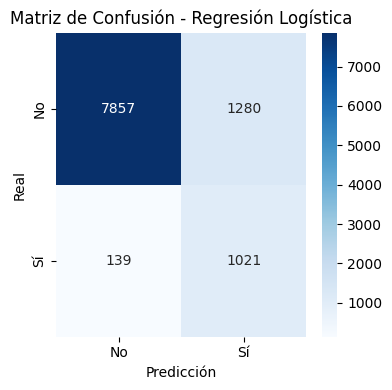

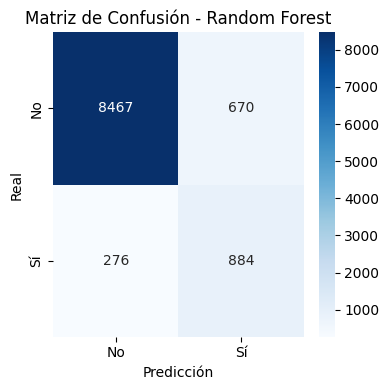

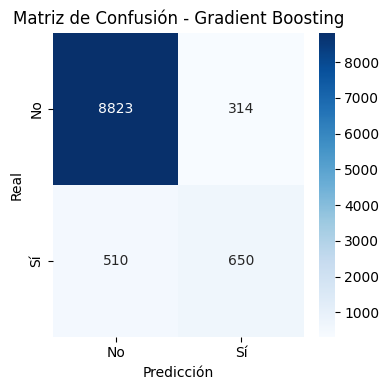

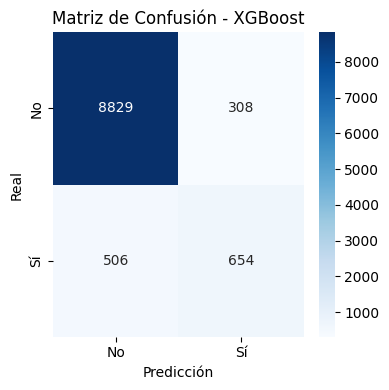

In [102]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, X_test, y_test, title):
    """
    Genera y muestra la matriz de confusión para cualquier modelo entrenado.
    """
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No', 'Sí'],
        yticklabels=['No', 'Sí']
    )
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title(f"Matriz de Confusión - {title}")
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(baseline, X_test, y_test, "Regresión Logística")
#plot_confusion_matrix(svm_best, X_test, y_test, "SVM")
plot_confusion_matrix(grid_rf.best_estimator_, X_test, y_test, "Random Forest")
plot_confusion_matrix(gbm_best, X_test, y_test, "Gradient Boosting")
plot_confusion_matrix(grid_xgb.best_estimator_, X_test, y_test, "XGBoost")

# Conclusión del análisis de modelos:

Se compararon cuatro modelos de clasificación para predecir la contratación de depósitos: Logistic Regression, Random Forest, Gradient Boosting y XGBoost.

Logistic Regression como baseline alcanzó Accuracy ≈ 0.862, F1 ≈ 0.590 y ROC-AUC ≈ 0.939.

Random Forest mejoró la predicción de clientes positivos con Accuracy ≈ 0.908, F1 ≈ 0.651 y ROC-AUC ≈ 0.948.

Gradient Boosting mostró un desempeño equilibrado con Accuracy ≈ 0.920, F1 ≈ 0.612 y ROC-AUC ≈ 0.950.

XGBoost obtuvo el mejor desempeño global, con Accuracy ≈ 0.921, F1 ≈ 0.616 y ROC-AUC ≈ 0.950, destacando por su capacidad de discriminar correctamente a los clientes que contratarían el depósito.

Resumen: Los modelos basados en árboles (Random Forest, Gradient Boosting y XGBoost) superan ampliamente al baseline, siendo XGBoost el modelo más recomendable para la campaña de marketing, ya que permite identificar con mayor precisión a los clientes que potencialmente aceptarían la oferta, optimizando los recursos en un escenario de marketing directo